In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

In [7]:
NG_PRICE_DIR = (Path.cwd().parents[1] / "01_data" / "3_analysis" / "ng_price").resolve()
RTM_PRICE_DIR = (Path.cwd().parents[1] / "01_data" / "2_cleaned" / "rtm_price" / "rtm_price_aggregated_2021_2025.csv").resolve()

In [8]:
df_ng_price = pd.read_csv(NG_PRICE_DIR / "ng_prices_monthly.csv")
df_ng_price["date"] = pd.to_datetime(df_ng_price["date"])
df_ng_price

,date,henry_hub,citygate,elec_pwr,outlier_citygate,outlier_elec_pwr
0,2002-01-01,2.317619,3.304432,2.552987,False,False
1,2002-02-01,2.323684,3.111753,2.273603,False,False
2,2002-03-01,3.028500,3.121387,2.851638,False,False
3,2002-04-01,3.426818,4.065511,3.439306,False,False
4,2002-05-01,3.498182,4.007707,3.391137,False,False
...,...,...,...,...,...,...
284,2025-10-01,3.186087,3.025048,2.610790,False,False
285,2025-11-01,3.794118,3.815029,3.121387,False,False
286,2025-12-01,4.263810,4.065511,3.179191,False,False
287,2026-01-01,7.717895,5.973025,6.078998,False,False


In [9]:
df_rtm_price = pd.read_csv(RTM_PRICE_DIR)
df_rtm_price

,date_time,avg_rtm_price,std_rtm_price
0,2021-01-01 01:00:00,18.714000,1.508854
1,2021-01-01 02:00:00,18.107333,1.512517
2,2021-01-01 03:00:00,17.570000,1.537424
3,2021-01-01 04:00:00,17.670667,1.540869
4,2021-01-01 05:00:00,17.792000,1.997417
...,...,...,...
43310,2025-12-27 20:00:00,17.682000,4.066851
43311,2025-12-27 21:00:00,15.002667,4.357721
43312,2025-12-27 22:00:00,13.227333,4.750020
43313,2025-12-27 23:00:00,14.328667,5.222993


In [11]:
# resample price to monthly
df_rtm_price["date_time"] = pd.to_datetime(df_rtm_price["date_time"])
df_rtm_price_monthly = df_rtm_price.set_index("date_time").resample("MS")['avg_rtm_price'].mean().reset_index()
df_rtm_price_monthly.rename(columns={"price": "rtm_price"}, inplace=True)
df_rtm_price_monthly.head()

,date_time,avg_rtm_price
0,2021-01-01,21.481099
1,2021-02-01,1485.067076
2,2021-03-01,19.461760
3,2021-04-01,29.063550
4,2021-05-01,24.407913


#### analysis of 2021-02 data

In [13]:
df_202102 = df_rtm_price[(df_rtm_price["date_time"].dt.year == 2021) & (df_rtm_price["date_time"].dt.month == 2)]
print(f'2021-02 RTM price statistics')
df_202102['avg_rtm_price'].describe()

2021-02 RTM price statistics


count     672.000000
mean     1485.067076
std      2904.038178
min        -0.840000
25%        18.382167
50%        24.904333
75%       374.945000
max      9001.180667
Name: avg_rtm_price, dtype: float64

In [14]:
df_202102

,date_time,avg_rtm_price,std_rtm_price
743,2021-02-01 00:00:00,20.736667,1.182423
744,2021-02-01 01:00:00,20.191333,1.865969
745,2021-02-01 02:00:00,18.938667,1.953184
746,2021-02-01 03:00:00,19.298000,1.993071
747,2021-02-01 04:00:00,20.293333,2.054739
...,...,...,...
1410,2021-02-28 19:00:00,26.586667,0.748004
1411,2021-02-28 20:00:00,19.712000,1.022924
1412,2021-02-28 21:00:00,17.205333,1.977859
1413,2021-02-28 22:00:00,15.173333,2.610218


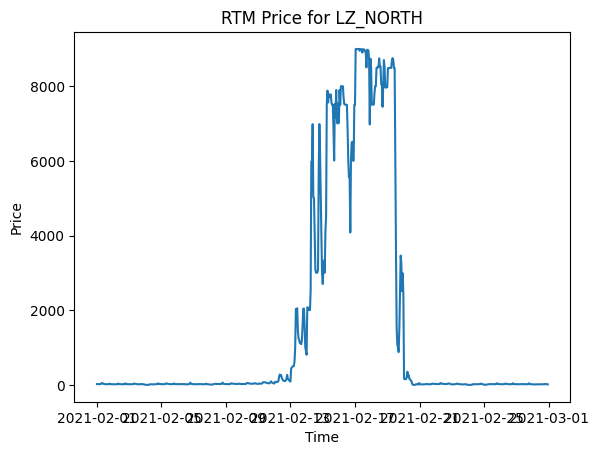

In [18]:
plt.plot(df_202102['date_time'], df_202102['avg_rtm_price'])
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('RTM Price for LZ_NORTH')
plt.show()

#### continue for correlation analysis 

In [20]:
merged_df = pd.merge(df_ng_price, df_rtm_price_monthly, left_on="date", right_on="date_time", how="inner")
merged_df['date'] = merged_df['date'].dt.to_period('M')
merged_df = merged_df[["date", "elec_pwr", "henry_hub", "avg_rtm_price"]]
merged_df.head()

,date,elec_pwr,henry_hub,avg_rtm_price
0,2021-01,2.793834,2.712632,21.481099
1,2021-02,59.614644,5.353684,1485.067076
2,2021-03,2.947977,2.618261,19.461760
3,2021-04,3.131021,2.662857,29.063550
4,2021-05,3.294798,2.912500,24.407913


In [22]:
# detect outliers in rtm_price
merged_df[merged_df['avg_rtm_price'] > 200]

,date,elec_pwr,henry_hub,avg_rtm_price
1,2021-02,59.614644,5.353684,1485.067076
31,2023-08,2.687861,2.583043,262.744116


In [23]:
def scatter_corr(x, y, xlabel, ylabel, title):
    methods_config = {
        "pearson": {
            "stat_fn": lambda x, y: stats.pearsonr(x, y),
            "symbol":  "r",
            "color":   "#E53935",
            "label":   "Pearson (OLS)",
        },
        "spearman": {
            "stat_fn": lambda x, y: stats.spearmanr(x, y),
            "symbol":  "ρ",
            "color":   "#046946",
            "label":   "Spearman (rank-OLS)",
        },
        "kendall": {
            "stat_fn": lambda x, y: stats.kendalltau(x, y),
            "symbol":  "τ",
            "color":   "#8E24AA",
            "label":   "Kendall (Theil-Sen)",
        },
    }

    ax = plt.gca()
    ax.scatter(x, y, s=14, alpha=0.55, color="#607D8B", edgecolors="none")

    xline = np.linspace(x.min(), x.max(), 200)
    annotation_lines = []

    for method, cfg in methods_config.items():
        stat, p = cfg["stat_fn"](x, y)
        pstr = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

        if method == "pearson":
            slope, intercept = np.polyfit(x, y, 1)
            yline = slope * xline + intercept

        elif method == "spearman":
            rx, ry = stats.rankdata(x), stats.rankdata(y)
            slope, intercept = np.polyfit(rx, ry, 1)
            # Convert evenly-spaced x values → their approximate ranks via percentile
            pcts = (xline - x.min()) / (x.max() - x.min()) * 100
            pcts = np.clip(pcts, 0, 100)
            x_ranks_interp = np.percentile(rx, pcts)
            y_ranks_interp = slope * x_ranks_interp + intercept
            # Convert predicted y-ranks back to y-values
            yline = np.percentile(y, np.clip(y_ranks_interp / ry.max() * 100, 0, 100))

        elif method == "kendall":
            slope, intercept, _, _ = stats.theilslopes(y, x)
            yline = slope * xline + intercept

        ax.plot(xline, yline, color=cfg["color"], lw=1.8,
                label=f"{cfg['label']}: {cfg['symbol']} = {stat:.3f}, {pstr}")
        annotation_lines.append(f"{cfg['symbol']} = {stat:.3f},  {pstr}")

    ax.plot(xline, xline, color="#000000", lw=1.2, ls="--", label="1:1 Line")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.35)

Saved → /Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/data/03_analysis/NG Price/rtm_ng_price_correlation.png


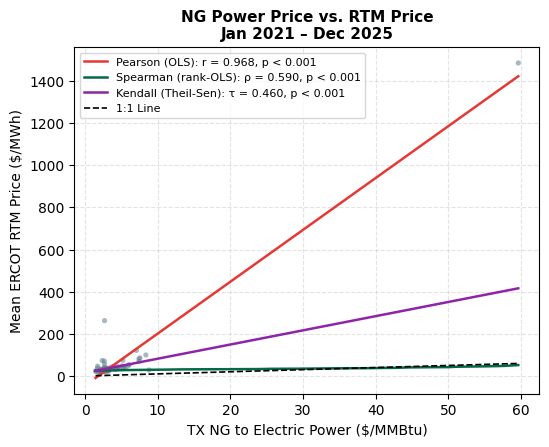

In [27]:
from matplotlib.pyplot import axes

date_range = f"{merged_df['date'].min().strftime('%b %Y')} \u2013 {merged_df['date'].max().strftime('%b %Y')}"

fig = plt.figure(figsize=(6, 4.5))
scatter_corr(
    x=merged_df["elec_pwr"], y=merged_df["avg_rtm_price"],
    xlabel="TX NG to Electric Power ($/MMBtu)",
    ylabel="Mean ERCOT RTM Price ($/MWh)",
    title=f"NG Power Price vs. RTM Price\n{date_range}"
)
out_corr = NG_PRICE_DIR / "rtm_ng_price_correlation.png"
fig.savefig(out_corr, dpi=150, bbox_inches="tight")
print(f"Saved \u2192 {out_corr}")
plt.show()

Saved → /Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/data/03_analysis/NG Price/rtm_ng_price_correlation_no_outliers.png


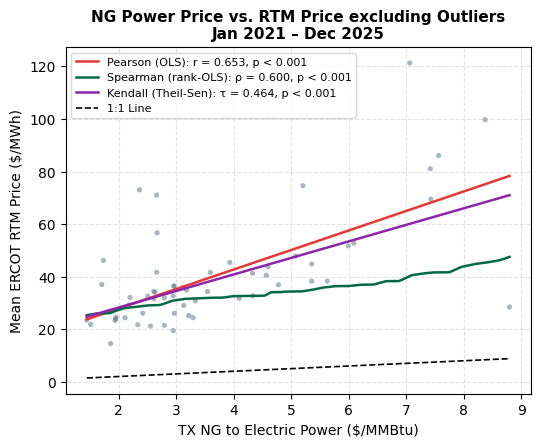

In [28]:
# plot again excluding outliers
df_no_outliers = merged_df[merged_df["avg_rtm_price"] < 200]

fig = plt.figure(figsize=(6, 4.5))
scatter_corr(
    x=df_no_outliers["elec_pwr"], y=df_no_outliers["avg_rtm_price"],
    xlabel="TX NG to Electric Power ($/MMBtu)",
    ylabel="Mean ERCOT RTM Price ($/MWh)",
    title=f"NG Power Price vs. RTM Price excluding Outliers\n{date_range}"
)
out_corr = NG_PRICE_DIR / "rtm_ng_price_correlation_no_outliers.png"
fig.savefig(out_corr, dpi=150, bbox_inches="tight")
print(f"Saved \u2192 {out_corr}")
plt.show()

Text(0.5, 1.0, 'Natural Gas Price vs. ERCOT Power Price (Excluding Outliers)')

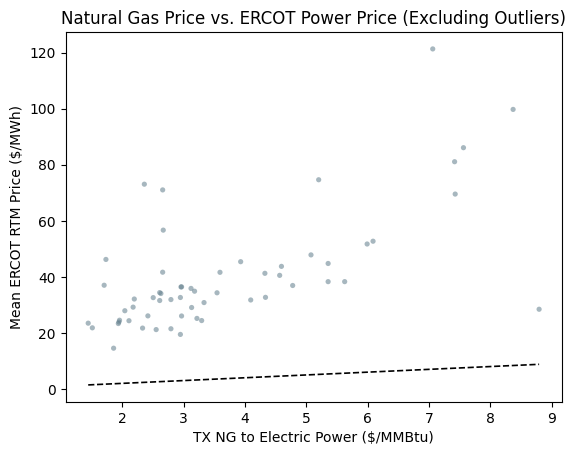

In [31]:
# simplified graph
x = df_no_outliers["elec_pwr"]
y = df_no_outliers["avg_rtm_price"]

plt.scatter(x, y, s=14, alpha=0.55, color="#607D8B", edgecolors="none")
xline = np.linspace(x.min(), x.max(), 200)
plt.plot(xline, xline, color="#000000", lw=1.2, ls="--", label="1:1 Line")

plt.xlabel("TX NG to Electric Power ($/MMBtu)")
plt.ylabel("Mean ERCOT RTM Price ($/MWh)")
plt.title('Natural Gas Price vs. ERCOT Power Price (Excluding Outliers)')


Saved → /Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/data/other sources/NG Price/rtm_henryhub_price_correlation.png


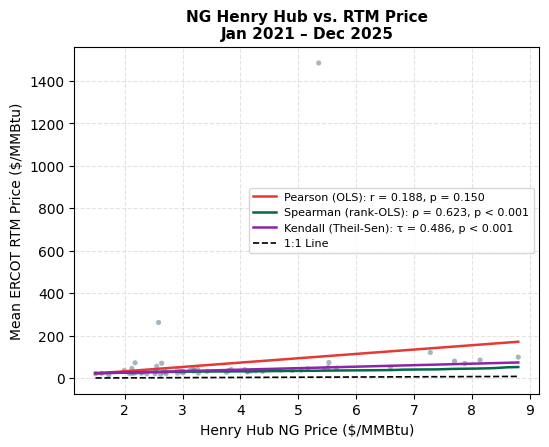

In [14]:
# henry hub and rtm price correlation
fig = plt.figure(figsize=(6, 4.5))
scatter_corr(
    x=merged_df["henry_hub"], y=merged_df["rtm_price"],
    xlabel="Henry Hub NG Price ($/MMBtu)",
    ylabel="Mean ERCOT RTM Price ($/MMBtu)",
    title=f"NG Henry Hub vs. RTM Price\n{date_range}"
)
out_corr = NG_PRICE_DIR / "rtm_henryhub_price_correlation.png"
fig.savefig(out_corr, dpi=150, bbox_inches="tight")
print(f"Saved \u2192 {out_corr}")
plt.show()

Saved → /Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/data/other sources/NG Price/rtm_henryhub_price_correlation_no_outliers.png


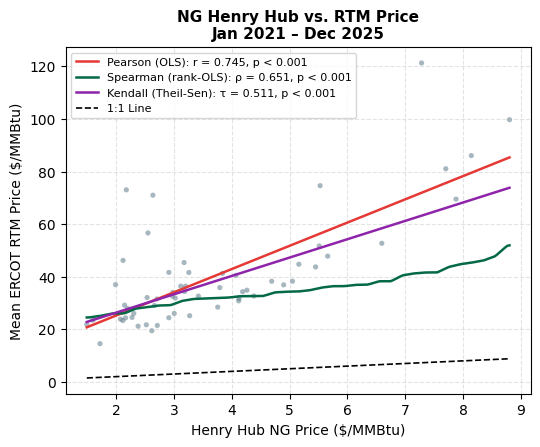

In [15]:
# henry hub and rtm price correlation
merged_df_no_outliers = merged_df[merged_df["rtm_price"] < 200]

fig = plt.figure(figsize=(6, 4.5))
scatter_corr(
    x=merged_df_no_outliers["henry_hub"], y=merged_df_no_outliers["rtm_price"],
    xlabel="Henry Hub NG Price ($/MMBtu)",
    ylabel="Mean ERCOT RTM Price ($/MMBtu)",
    title=f"NG Henry Hub vs. RTM Price\n{date_range}"
)
out_corr = NG_PRICE_DIR / "rtm_henryhub_price_correlation_no_outliers.png"
fig.savefig(out_corr, dpi=150, bbox_inches="tight")
print(f"Saved \u2192 {out_corr}")
plt.show()